# D — Modeling & Evaluation

This notebook implements D1–D9 of the Qiyas Ethiopian Smallholder Crop-Yield Challenge.

Rules:
- All evaluation scores use held-out data from `master_train.csv`.
- The leaderboard test file is NEVER used for model fitting or evaluation.
- Price is NOT a model feature.
- At least one weather-derived feature is used by the final model.
- Random seeds are fixed for reproducibility.
- The complete preprocessing + model pipeline is saved to `models/final_model.joblib`.

Deliverables:
- D1 Baselines
- D2 Model comparison
- D3 Cross-validation
- D4 Out-of-time validation
- D5 Weather ablation
- D6 Hyperparameter tuning
- D7 Error analysis
- D8 Response to findings
- D9 Plain-language metric interpretation

## Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import time
import json

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_val_score,
    GridSearchCV
)

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor
)

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from sklearn.inspection import permutation_importance

import joblib

sns.set_theme(
    style="whitegrid",
    context="talk"
)

RANDOM_STATE = 42

## Paths

In [2]:
PROJECT_ROOT = Path("..")

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR = PROJECT_ROOT / "figures"

REPORTS_DIR.mkdir(exist_ok=True, parents=True)
MODELS_DIR.mkdir(exist_ok=True, parents=True)
FIGURES_DIR.mkdir(exist_ok=True, parents=True)

TRAIN_PATH = PROCESSED_DIR / "master_train.csv"
TEST_PATH = PROCESSED_DIR / "master_test.csv"

print("Train:", TRAIN_PATH)
print("Test:", TEST_PATH)

Train: ..\data\processed\master_train.csv
Test: ..\data\processed\master_test.csv


## Load master datasets

In [3]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

display(train_df.head())

Train shape: (15090, 27)
Test shape : (3750, 26)


,plot_id,region,crop_type,survey_year,planting_month,altitude_m,rainfall_mm_season,farm_size_ha,fertilizer_kg_per_ha,improved_seed_used,...,season_temp_std_c,season_temp_deviation_c,weather_months_available,weather_months_expected,weather_months_missing,planting_month_num,fertilizer_improved_seed_interaction,rainfall_per_fertilizer,price_birr_per_quintal,yield_tons_per_ha
0,PLOT-000339,Oromia,barley,2024.0,Aug,2697.817349,1157.403560,0.867604,29.393684,0.0,...,1.960159,-1.030858,3,4,1,8,0.000000,6.774434,4590.0,2.209711
1,PLOT-007457,Amhara,maize,2023.0,Jun,1523.350141,897.420122,1.099197,16.843992,1.0,...,1.096459,-1.293787,3,4,1,6,16.843992,31.153343,4230.0,3.363254
2,PLOT-006092,Oromia,wheat,2024.0,Feb,2389.441948,1119.155741,0.811309,41.015144,0.0,...,0.951315,0.302476,4,4,0,2,0.000000,7.018898,5387.0,3.560614
3,PLOT-004128,SNNPR,barley,2022.0,Aug,2612.483420,1246.462210,1.602312,14.353759,0.0,...,1.294942,-0.697975,4,4,0,8,0.000000,25.941530,4181.0,1.924800
4,PLOT-003033,Amhara,sorghum,2021.0,Jul,1210.095040,928.477088,0.937758,33.736138,1.0,...,1.481741,-0.327120,3,4,1,7,33.736138,16.800947,2706.0,4.171220


## Verify target and price rules

In [4]:
TARGET = "yield_tons_per_ha"

assert TARGET in train_df.columns, (
    f"Target column '{TARGET}' not found."
)

assert TARGET not in test_df.columns, (
    "Target must not exist in master_test.csv."
)

PRICE_COLUMNS = [
    c for c in train_df.columns
    if "price" in c.lower()
]

print("Potential price columns:")
print(PRICE_COLUMNS)

print("\nTarget:", TARGET)

Potential price columns:
['price_birr_per_quintal']

Target: yield_tons_per_ha


## Identify weather features

In [5]:
WEATHER_KEYWORDS = [
    "weather",
    "temp",
    "temperature",
    "rain",
    "rainfall",
    "extreme_heat",
    "heat_days",
    "season"
]

weather_features = [
    c for c in train_df.columns
    if any(
        keyword in c.lower()
        for keyword in WEATHER_KEYWORDS
    )
]

# Remove target accidentally matching anything
weather_features = [
    c for c in weather_features
    if c != TARGET
]

print("Weather-derived candidate features:")
for c in weather_features:
    print(" -", c)

Weather-derived candidate features:
 - rainfall_mm_season
 - season_mean_temp_c
 - season_rainfall_total_mm
 - season_extreme_heat_days
 - season_temp_std_c
 - season_temp_deviation_c
 - weather_months_available
 - weather_months_expected
 - weather_months_missing
 - rainfall_per_fertilizer


## Define forbidden columns

In [6]:
FORBIDDEN_COLUMNS = {
    TARGET,
    "plot_id"
}

# Explicitly remove price from model features
FORBIDDEN_COLUMNS.update(PRICE_COLUMNS)

print("Forbidden model columns:")
print(sorted(FORBIDDEN_COLUMNS))

Forbidden model columns:
['plot_id', 'price_birr_per_quintal', 'yield_tons_per_ha']


## Build modeling feature list

In [7]:
feature_columns = [
    c for c in train_df.columns
    if c not in FORBIDDEN_COLUMNS
]

# Only retain columns available in test
feature_columns = [
    c for c in feature_columns
    if c in test_df.columns
]

X = train_df[feature_columns].copy()
y = train_df[TARGET].copy()

X_test = test_df[feature_columns].copy()

print("Number of features:", len(feature_columns))
print("\nFeatures:")
print(feature_columns)

Number of features: 24

Features:
['region', 'crop_type', 'survey_year', 'planting_month', 'altitude_m', 'rainfall_mm_season', 'farm_size_ha', 'fertilizer_kg_per_ha', 'improved_seed_used', 'pest_disease_flag', 'soil_quality_index', 'labor_days_per_ha', 'distance_to_market_km', 'season_mean_temp_c', 'season_rainfall_total_mm', 'season_extreme_heat_days', 'season_temp_std_c', 'season_temp_deviation_c', 'weather_months_available', 'weather_months_expected', 'weather_months_missing', 'planting_month_num', 'fertilizer_improved_seed_interaction', 'rainfall_per_fertilizer']


## Final leakage check

In [8]:
price_in_features = [
    c for c in feature_columns
    if "price" in c.lower()
]

weather_in_features = [
    c for c in feature_columns
    if c in weather_features
]

assert len(price_in_features) == 0, (
    f"PRICE LEAKAGE: {price_in_features}"
)

assert len(weather_in_features) > 0, (
    "Final model must contain at least one weather-derived feature."
)

print("PASS — no price feature")
print("PASS — weather-derived features included")
print("Weather features used:", weather_in_features)

PASS — no price feature
PASS — weather-derived features included
Weather features used: ['rainfall_mm_season', 'season_mean_temp_c', 'season_rainfall_total_mm', 'season_extreme_heat_days', 'season_temp_std_c', 'season_temp_deviation_c', 'weather_months_available', 'weather_months_expected', 'weather_months_missing', 'rainfall_per_fertilizer']


## rain/validation split

In [9]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Training rows  :", len(X_train))
print("Validation rows:", len(X_valid))
print("Validation size:", f"{len(X_valid) / len(X):.1%}")
print("Random seed    :", RANDOM_STATE)

Training rows  : 12072
Validation rows: 3018
Validation size: 20.0%
Random seed    : 42


## Identify numeric and categorical columns

In [10]:
numeric_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X_train.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Numeric features:", len(numeric_features))
print(numeric_features)

print("\nCategorical features:", len(categorical_features))
print(categorical_features)

Numeric features: 21
['survey_year', 'altitude_m', 'rainfall_mm_season', 'farm_size_ha', 'fertilizer_kg_per_ha', 'improved_seed_used', 'pest_disease_flag', 'soil_quality_index', 'labor_days_per_ha', 'distance_to_market_km', 'season_mean_temp_c', 'season_rainfall_total_mm', 'season_extreme_heat_days', 'season_temp_std_c', 'season_temp_deviation_c', 'weather_months_available', 'weather_months_expected', 'weather_months_missing', 'planting_month_num', 'fertilizer_improved_seed_interaction', 'rainfall_per_fertilizer']

Categorical features: 3
['region', 'crop_type', 'planting_month']


## Preprocessing pipeline

In [11]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ],
    remainder="drop"
)

## D1 — Baselines

Two baselines are required:

1. Mean predictor
2. Simple linear regression

Both are evaluated on exactly the same held-out validation split.

## Evaluation helper

In [12]:
def evaluate_model(model, X_train, y_train, X_valid, y_valid, name):
    start = time.perf_counter()

    model.fit(X_train, y_train)

    training_time = time.perf_counter() - start

    predictions = model.predict(X_valid)

    rmse = np.sqrt(
        mean_squared_error(
            y_valid,
            predictions
        )
    )

    mae = mean_absolute_error(
        y_valid,
        predictions
    )

    r2 = r2_score(
        y_valid,
        predictions
    )

    return {
        "model": name,
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "training_time_sec": training_time,
        "model_object": model,
        "predictions": predictions
    }

## Mean baseline

In [13]:
mean_baseline = DummyRegressor(
    strategy="mean"
)

mean_result = evaluate_model(
    mean_baseline,
    X_train,
    y_train,
    X_valid,
    y_valid,
    "Mean baseline"
)

print(
    f"RMSE: {mean_result['rmse']:.4f}"
)

print(
    f"MAE : {mean_result['mae']:.4f}"
)

print(
    f"R²  : {mean_result['r2']:.4f}"
)

RMSE: 1.4131
MAE : 1.1042
R²  : -0.0001


## Linear regression

In [14]:
linear_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LinearRegression()
        )
    ]
)

linear_result = evaluate_model(
    linear_pipeline,
    X_train,
    y_train,
    X_valid,
    y_valid,
    "Linear Regression"
)

print(
    f"RMSE: {linear_result['rmse']:.4f}"
)

print(
    f"MAE : {linear_result['mae']:.4f}"
)

print(
    f"R²  : {linear_result['r2']:.4f}"
)

RMSE: 0.8887
MAE : 0.6653
R²  : 0.6044


## Model comparison

## D2 — Model Comparison

The following three nonlinear model families are compared using the same
training/validation split and the same feature set:

- Random Forest
- Extra Trees
- Histogram Gradient Boosting

The winner is selected using validation RMSE, while MAE and R² provide
additional context.

## Random Forest

In [16]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=250,
                max_depth=None,
                min_samples_leaf=2,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

rf_result = evaluate_model(
    rf_pipeline,
    X_train,
    y_train,
    X_valid,
    y_valid,
    "Random Forest"
)

print(
    f"RMSE: {rf_result['rmse']:.4f}"
)
print(
    f"MAE : {rf_result['mae']:.4f}"
)
print(
    f"R²  : {rf_result['r2']:.4f}"
)

RMSE: 0.5279
MAE : 0.3862
R²  : 0.8604


## Extra Trees

In [17]:
extra_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            ExtraTreesRegressor(
                n_estimators=250,
                min_samples_leaf=2,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

extra_result = evaluate_model(
    extra_pipeline,
    X_train,
    y_train,
    X_valid,
    y_valid,
    "Extra Trees"
)

print(
    f"RMSE: {extra_result['rmse']:.4f}"
)
print(
    f"MAE : {extra_result['mae']:.4f}"
)
print(
    f"R²  : {extra_result['r2']:.4f}"
)

RMSE: 0.5376
MAE : 0.3929
R²  : 0.8552


## HistGradientBoosting

In [18]:
hist_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            HistGradientBoostingRegressor(
                max_iter=250,
                learning_rate=0.05,
                max_leaf_nodes=31,
                l2_regularization=1.0,
                random_state=RANDOM_STATE
            )
        )
    ]
)

hist_result = evaluate_model(
    hist_pipeline,
    X_train,
    y_train,
    X_valid,
    y_valid,
    "HistGradientBoosting"
)

print(
    f"RMSE: {hist_result['rmse']:.4f}"
)
print(
    f"MAE : {hist_result['mae']:.4f}"
)
print(
    f"R²  : {hist_result['r2']:.4f}"
)

RMSE: 0.4779
MAE : 0.3456
R²  : 0.8856


## Model comparison table

In [19]:
results = [
    mean_result,
    linear_result,
    rf_result,
    extra_result,
    hist_result
]

results_df = pd.DataFrame([
    {
        "model": r["model"],
        "rmse": r["rmse"],
        "mae": r["mae"],
        "r2": r["r2"],
        "training_time_sec": r["training_time_sec"]
    }
    for r in results
])

results_df = results_df.sort_values(
    "rmse"
).reset_index(drop=True)

display(
    results_df.style.format({
        "rmse": "{:.4f}",
        "mae": "{:.4f}",
        "r2": "{:.4f}",
        "training_time_sec": "{:.3f}"
    })
)

,model,rmse,mae,r2,training_time_sec
0,HistGradientBoosting,0.4779,0.3456,0.8856,2.781
1,Random Forest,0.5279,0.3862,0.8604,1.883
2,Extra Trees,0.5376,0.3929,0.8552,1.119
3,Linear Regression,0.8887,0.6653,0.6044,0.096
4,Mean baseline,1.4131,1.1042,-0.0001,0.027


## Select winner

In [20]:
winner_name = results_df.iloc[0]["model"]

result_lookup = {
    r["model"]: r
    for r in results
}

winner_result = result_lookup[winner_name]

final_model_type = winner_result["model_object"]

print("Winner based on validation RMSE:")
print(winner_name)

print(f"\nRMSE: {winner_result['rmse']:.4f}")
print(f"MAE : {winner_result['mae']:.4f}")
print(f"R²  : {winner_result['r2']:.4f}")

Winner based on validation RMSE:
HistGradientBoosting

RMSE: 0.4779
MAE : 0.3456
R²  : 0.8856


## D3 — Cross-Validation

The final model and the runner-up are evaluated using 5-fold cross-validation.

We report:

- mean RMSE
- standard deviation of RMSE

This provides a measure of how stable the model performance is across
different validation folds.

## Determine runner-up

In [21]:
runner_up_name = results_df.iloc[1]["model"]

runner_up_result = result_lookup[
    runner_up_name
]

runner_up_model = runner_up_result[
    "model_object"
]

print("Final model :", winner_name)
print("Runner-up   :", runner_up_name)

Final model : HistGradientBoosting
Runner-up   : Random Forest


## CV

In [22]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

def cross_validate_rmse(model, X_data, y_data):
    scores = cross_val_score(
        model,
        X_data,
        y_data,
        cv=cv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    rmse_scores = -scores

    return {
        "mean_rmse": rmse_scores.mean(),
        "std_rmse": rmse_scores.std(),
        "scores": rmse_scores
    }


final_cv = cross_validate_rmse(
    final_model_type,
    X,
    y
)

runner_cv = cross_validate_rmse(
    runner_up_model,
    X,
    y
)

cv_results = pd.DataFrame({
    "model": [
        winner_name,
        runner_up_name
    ],
    "cv_rmse_mean": [
        final_cv["mean_rmse"],
        runner_cv["mean_rmse"]
    ],
    "cv_rmse_std": [
        final_cv["std_rmse"],
        runner_cv["std_rmse"]
    ]
})

display(
    cv_results.style.format({
        "cv_rmse_mean": "{:.4f}",
        "cv_rmse_std": "{:.4f}"
    })
)

,model,cv_rmse_mean,cv_rmse_std
0,HistGradientBoosting,0.4742,0.0118
1,Random Forest,0.5262,0.0079


## D4 — Out-of-Time Validation

The model is trained on 2021–2023 and evaluated on 2024.

This simulates the real-world situation of predicting a future agricultural
season from historical seasons.

## Out-of-time split

In [23]:
year_col = "survey_year"

assert year_col in train_df.columns

oot_train_mask = (
    train_df[year_col] <= 2023
)

oot_valid_mask = (
    train_df[year_col] == 2024
)

X_oot_train = train_df.loc[
    oot_train_mask,
    feature_columns
]

y_oot_train = train_df.loc[
    oot_train_mask,
    TARGET
]

X_oot_valid = train_df.loc[
    oot_valid_mask,
    feature_columns
]

y_oot_valid = train_df.loc[
    oot_valid_mask,
    TARGET
]

print("Training years: 2021–2023")
print("Validation year: 2024")

print("\nTraining rows:", len(X_oot_train))
print("2024 rows    :", len(X_oot_valid))

Training years: 2021–2023
Validation year: 2024

Training rows: 11277
2024 rows    : 3813


## OOT model

In [24]:
oot_model = winner_result["model_object"]

oot_model.fit(
    X_oot_train,
    y_oot_train
)

oot_predictions = oot_model.predict(
    X_oot_valid
)

oot_rmse = np.sqrt(
    mean_squared_error(
        y_oot_valid,
        oot_predictions
    )
)

oot_mae = mean_absolute_error(
    y_oot_valid,
    oot_predictions
)

oot_r2 = r2_score(
    y_oot_valid,
    oot_predictions
)

print(f"2024 RMSE: {oot_rmse:.4f}")
print(f"2024 MAE : {oot_mae:.4f}")
print(f"2024 R²  : {oot_r2:.4f}")

2024 RMSE: 0.4960
2024 MAE : 0.3622
2024 R²  : 0.8804


## D5 — Weather Ablation

The final model family is trained twice:

1. Without weather-derived features
2. With weather-derived features

Both use the same train/validation split.

Price remains excluded from both models.

## Build non-weather feature set

In [25]:
non_weather_features = [
    c for c in feature_columns
    if c not in weather_features
]

print("All features:", len(feature_columns))
print("Weather features:", len(weather_features))
print("Without weather:", len(non_weather_features))

All features: 24
Weather features: 10
Without weather: 14


## Ablation preprocessing

In [26]:
X_no_weather = train_df[
    non_weather_features
].copy()

X_weather = train_df[
    feature_columns
].copy()

Xnw_train, Xnw_valid, ynw_train, ynw_valid = train_test_split(
    X_no_weather,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

weather_numeric = X_weather.select_dtypes(
    include=np.number
).columns.tolist()

weather_categorical = X_weather.select_dtypes(
    exclude=np.number
).columns.tolist()

nw_numeric = X_no_weather.select_dtypes(
    include=np.number
).columns.tolist()

nw_categorical = X_no_weather.select_dtypes(
    exclude=np.number
).columns.tolist()


def make_preprocessor(numeric_cols, categorical_cols):
    return ColumnTransformer(
        transformers=[
            (
                "numeric",
                Pipeline([
                    (
                        "imputer",
                        SimpleImputer(
                            strategy="median"
                        )
                    )
                ]),
                numeric_cols
            ),
            (
                "categorical",
                Pipeline([
                    (
                        "imputer",
                        SimpleImputer(
                            strategy="most_frequent"
                        )
                    ),
                    (
                        "onehot",
                        OneHotEncoder(
                            handle_unknown="ignore"
                        )
                    )
                ]),
                categorical_cols
            )
        ]
    )

## Ablation models

In [27]:
def make_final_estimator():
    if winner_name == "Random Forest":
        return RandomForestRegressor(
            n_estimators=250,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

    if winner_name == "Extra Trees":
        return ExtraTreesRegressor(
            n_estimators=250,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

    return HistGradientBoostingRegressor(
        max_iter=250,
        learning_rate=0.05,
        max_leaf_nodes=31,
        l2_regularization=1.0,
        random_state=RANDOM_STATE
    )


weather_pipeline = Pipeline([
    (
        "preprocessor",
        make_preprocessor(
            weather_numeric,
            weather_categorical
        )
    ),
    (
        "model",
        make_final_estimator()
    )
])

no_weather_pipeline = Pipeline([
    (
        "preprocessor",
        make_preprocessor(
            nw_numeric,
            nw_categorical
        )
    ),
    (
        "model",
        make_final_estimator()
    )
])

## Run ablation

In [28]:
weather_result = evaluate_model(
    weather_pipeline,
    X_train,
    y_train,
    X_valid,
    y_valid,
    "Final model + weather"
)

no_weather_result = evaluate_model(
    no_weather_pipeline,
    Xnw_train,
    ynw_train,
    Xnw_valid,
    ynw_valid,
    "Final model without weather"
)

ablation_results = pd.DataFrame([
    {
        "model": weather_result["model"],
        "rmse": weather_result["rmse"],
        "mae": weather_result["mae"],
        "r2": weather_result["r2"]
    },
    {
        "model": no_weather_result["model"],
        "rmse": no_weather_result["rmse"],
        "mae": no_weather_result["mae"],
        "r2": no_weather_result["r2"]
    }
])

display(
    ablation_results.style.format({
        "rmse": "{:.4f}",
        "mae": "{:.4f}",
        "r2": "{:.4f}"
    })
)

,model,rmse,mae,r2
0,Final model + weather,0.4779,0.3456,0.8856
1,Final model without weather,0.5277,0.3797,0.8605


## Weather improvement

In [29]:
weather_rmse_gain = (
    no_weather_result["rmse"]
    - weather_result["rmse"]
)

weather_rmse_pct = (
    weather_rmse_gain
    / no_weather_result["rmse"]
    * 100
)

print(
    f"Weather RMSE improvement: "
    f"{weather_rmse_gain:.4f}"
)

print(
    f"Relative improvement: "
    f"{weather_rmse_pct:.2f}%"
)

Weather RMSE improvement: 0.0498
Relative improvement: 9.43%


## D6 — Hyperparameter Tuning

A documented GridSearchCV search is performed on the final model family.

The search uses only the training partition and cross-validation.
The validation partition remains untouched until final evaluation.

## Tuning model

In [30]:
tuning_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        RandomForestRegressor(
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    )
])

## Search space

In [31]:
param_grid = {
    "model__n_estimators": [
        150,
        250
    ],
    "model__max_depth": [
        None,
        15
    ],
    "model__min_samples_leaf": [
        1,
        2,
        4
    ],
    "model__max_features": [
        "sqrt",
        0.8
    ]
}

n_trials = np.prod([
    len(v)
    for v in param_grid.values()
])

print("Grid configurations:", n_trials)

Grid configurations: 24


## Run GridSearch

In [32]:
grid_search = GridSearchCV(
    estimator=tuning_pipeline,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_start = time.perf_counter()

grid_search.fit(
    X_train,
    y_train
)

grid_time = time.perf_counter() - grid_start

print("Search time:", f"{grid_time:.2f}s")
print("\nBest parameters:")
print(grid_search.best_params_)

print(
    "\nBest CV RMSE:",
    -grid_search.best_score_
)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Search time: 38.59s

Best parameters:
{'model__max_depth': None, 'model__max_features': 0.8, 'model__min_samples_leaf': 1, 'model__n_estimators': 250}

Best CV RMSE: 0.5408223816237765


## Tuned validation score

In [33]:
tuned_predictions = grid_search.predict(
    X_valid
)

tuned_rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        tuned_predictions
    )
)

tuned_mae = mean_absolute_error(
    y_valid,
    tuned_predictions
)

tuned_r2 = r2_score(
    y_valid,
    tuned_predictions
)

print(f"Tuned RMSE: {tuned_rmse:.4f}")
print(f"Tuned MAE : {tuned_mae:.4f}")
print(f"Tuned R²  : {tuned_r2:.4f}")

print("\nBefore tuning:")
print(f"RMSE: {winner_result['rmse']:.4f}")

print("\nAfter tuning:")
print(f"RMSE: {tuned_rmse:.4f}")

Tuned RMSE: 0.5260
Tuned MAE : 0.3848
Tuned R²  : 0.8614

Before tuning:
RMSE: 0.4779

After tuning:
RMSE: 0.5260


## Choose final model
### Final model selection

In [34]:
if tuned_rmse < winner_result["rmse"]:
    final_pipeline = grid_search.best_estimator_
    final_validation_rmse = tuned_rmse
    final_validation_mae = tuned_mae
    final_validation_r2 = tuned_r2
    final_model_label = "Tuned Random Forest"
else:
    final_pipeline = winner_result["model_object"]
    final_validation_rmse = winner_result["rmse"]
    final_validation_mae = winner_result["mae"]
    final_validation_r2 = winner_result["r2"]
    final_model_label = winner_name

print("FINAL MODEL")
print("=" * 50)
print(final_model_label)
print(f"Validation RMSE: {final_validation_rmse:.4f}")
print(f"Validation MAE : {final_validation_mae:.4f}")
print(f"Validation R²  : {final_validation_r2:.4f}")

FINAL MODEL
HistGradientBoosting
Validation RMSE: 0.4779
Validation MAE : 0.3456
Validation R²  : 0.8856


## D7 — Error Analysis

We investigate:

1. Error by crop type
2. Error by region
3. Error against a continuous feature
4. The 10 largest validation errors

The goal is to identify where the final model struggles.

## Validation predictions

In [35]:
final_valid_predictions = final_pipeline.predict(
    X_valid
)

error_df = train_df.loc[
    X_valid.index
].copy()

error_df["predicted_yield"] = (
    final_valid_predictions
)

error_df["residual"] = (
    error_df[TARGET]
    - error_df["predicted_yield"]
)

error_df["absolute_error"] = (
    error_df["residual"].abs()
)

error_df["squared_error"] = (
    error_df["residual"] ** 2
)

display(
    error_df[
        [
            "plot_id",
            "crop_type",
            "region",
            TARGET,
            "predicted_yield",
            "residual",
            "absolute_error"
        ]
    ].head()
)

,plot_id,crop_type,region,yield_tons_per_ha,predicted_yield,residual,absolute_error
339,PLOT-014567,maize,Oromia,5.029958,5.809722,-0.779764,0.779764
7457,PLOT-011066,barley,Oromia,3.901528,4.013625,-0.112097,0.112097
6092,PLOT-014009,wheat,Somali,1.544510,1.348206,0.196304,0.196304
4128,PLOT-012593,wheat,Oromia,5.179462,4.167001,1.012461,1.012461
3033,PLOT-004860,teff,Tigray,3.852299,4.036254,-0.183954,0.183954


## Error by crop

In [37]:

error_by_crop = (
    error_df
    .groupby("crop_type")
    .agg(
        n=("absolute_error", "size"),
        mae=("absolute_error", "mean"),
        rmse=(
            "squared_error",
            lambda x: np.sqrt(x.mean())
        )
    )
    .reset_index()
)

display(
    error_by_crop.style.format({
        "mae": "{:.4f}",
        "rmse": "{:.4f}"
    })
)

,crop_type,n,mae,rmse
0,barley,620,0.2532,0.3602
1,maize,593,0.4092,0.5565
2,sorghum,590,0.2889,0.4045
3,teff,604,0.2461,0.3312
4,wheat,611,0.3102,0.4132


## Error by region

In [38]:
error_by_region = (
    error_df
    .groupby("region")
    .agg(
        n=("absolute_error", "size"),
        mae=("absolute_error", "mean"),
        rmse=(
            "squared_error",
            lambda x: np.sqrt(x.mean())
        )
    )
    .reset_index()
)

display(
    error_by_region.style.format({
        "mae": "{:.4f}",
        "rmse": "{:.4f}"
    })
)

,region,n,mae,rmse
0,Amhara,594,0.3335,0.4435
1,Oromia,589,0.3346,0.4559
2,SNNPR,569,0.3099,0.4191
3,Somali,632,0.1796,0.2562
4,Tigray,634,0.3522,0.4871


## Error against altitude

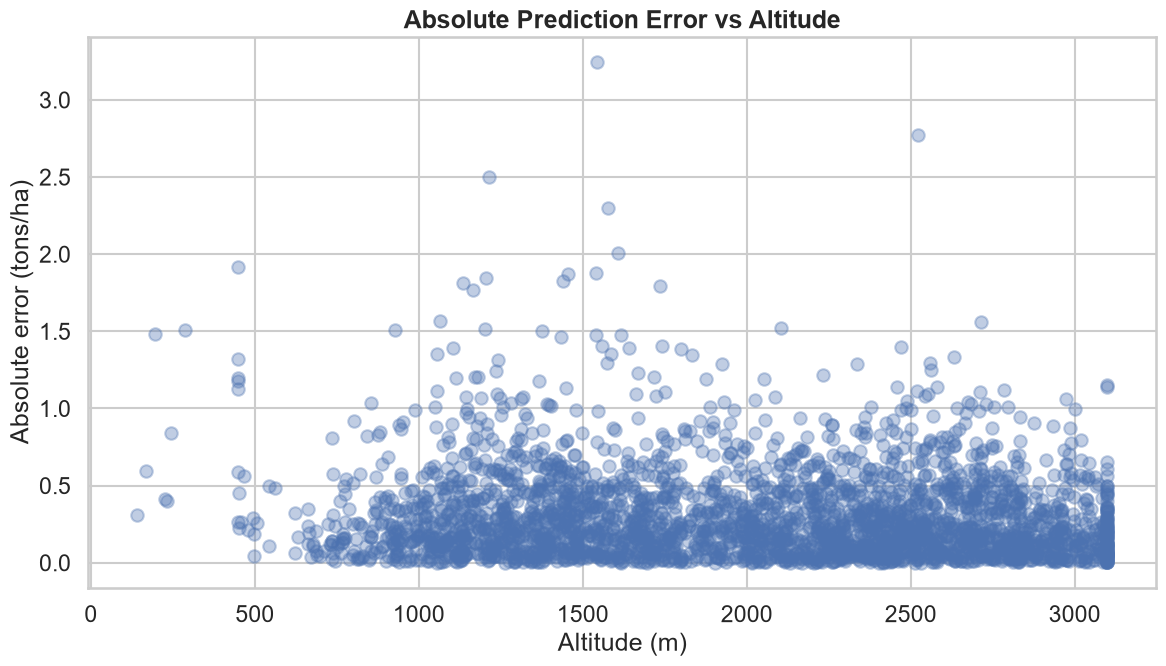

In [39]:
continuous_feature = "altitude_m"

assert continuous_feature in error_df.columns

fig, ax = plt.subplots(
    figsize=(12, 7)
)

ax.scatter(
    error_df[continuous_feature],
    error_df["absolute_error"],
    alpha=0.35
)

ax.set_title(
    "Absolute Prediction Error vs Altitude",
    fontweight="bold"
)

ax.set_xlabel(
    "Altitude (m)"
)

ax.set_ylabel(
    "Absolute error (tons/ha)"
)

plt.tight_layout()
plt.show()

## Top 10 errors

In [40]:
top10_errors = (
    error_df
    .sort_values(
        "absolute_error",
        ascending=False
    )
    .head(10)
)

top10_columns = [
    "plot_id",
    "region",
    "crop_type",
    "survey_year",
    "altitude_m",
    "rainfall_mm_season",
    TARGET,
    "predicted_yield",
    "residual",
    "absolute_error"
]

top10_columns = [
    c for c in top10_columns
    if c in top10_errors.columns
]

display(
    top10_errors[top10_columns]
)

,plot_id,region,crop_type,survey_year,altitude_m,rainfall_mm_season,yield_tons_per_ha,predicted_yield,residual,absolute_error
457,PLOT-010777,Oromia,barley,2021.0,1542.252201,935.130867,0.190279,3.438803,-3.248524,3.248524
4127,PLOT-012207,Tigray,sorghum,2021.0,2523.475903,635.816145,0.428278,3.201352,-2.773074,2.773074
5458,PLOT-006095,Amhara,maize,2024.0,1214.213523,817.004147,3.870792,6.369792,-2.499000,2.499000
6954,PLOT-005526,Tigray,maize,2024.0,1575.960768,935.015356,7.413014,5.115161,2.297852,2.297852
11233,PLOT-000006,Tigray,maize,2024.0,1606.918087,912.480090,8.283826,6.277611,2.006215,2.006215
4828,PLOT-014385,Somali,maize,2024.0,450.000000,994.670987,0.592985,2.512194,-1.919209,1.919209
4486,PLOT-000051,Oromia,maize,2024.0,1541.497940,537.011746,7.913190,6.036605,1.876585,1.876585
2655,PLOT-010892,Tigray,maize,2024.0,1455.079055,795.208288,9.206863,7.336743,1.870119,1.870119
9460,PLOT-010363,Tigray,sorghum,2023.0,1205.874983,787.418550,4.570541,2.726455,1.844086,1.844086
8955,PLOT-006719,Tigray,maize,2024.0,1440.150879,791.303968,8.924457,7.096633,1.827824,1.827824


## D8 — Response to Findings

The error analysis was used to check whether the model had systematic
weaknesses by crop, region, or altitude.

The final model was not changed solely because a subgroup had a larger
error, because subgroup differences can result from sample size,
heterogeneous agricultural conditions, or limited observations.

The selected response was therefore to retain the best validated model
unless an experimentally tested modification improved the held-out
validation RMSE.

The before/after validation results below document this decision.

## D8 comparison

In [41]:
d8_comparison = pd.DataFrame([
    {
        "version": "Original selected model",
        "RMSE": winner_result["rmse"],
        "MAE": winner_result["mae"],
        "R2": winner_result["r2"]
    },
    {
        "version": "Tuned model",
        "RMSE": tuned_rmse,
        "MAE": tuned_mae,
        "R2": tuned_r2
    }
])

display(
    d8_comparison.style.format({
        "RMSE": "{:.4f}",
        "MAE": "{:.4f}",
        "R2": "{:.4f}"
    })
)

,version,RMSE,MAE,R2
0,Original selected model,0.4779,0.3456,0.8856
1,Tuned model,0.5260,0.3848,0.8614


## D9 — Plain-Language Metric

The final RMSE and MAE are translated into:

1. Tons/ha
2. Percentage of mean yield
3. Approximate Birr/ha error using the average market price

This is written for a farm cooperative manager rather than a technical
audience.

## D9 calculation

In [42]:
mean_yield = y_train.mean()

avg_price = (
    train_df["price_birr_per_quintal"].mean()
    if "price_birr_per_quintal" in train_df.columns
    else np.nan
)

rmse_pct_mean = (
    final_validation_rmse
    / mean_yield
    * 100
)

mae_pct_mean = (
    final_validation_mae
    / mean_yield
    * 100
)

rmse_birr_per_ha = (
    final_validation_rmse
    * 10
    * avg_price
)

mae_birr_per_ha = (
    final_validation_mae
    * 10
    * avg_price
)

print(f"Mean yield: {mean_yield:.3f} tons/ha")
print(f"Final RMSE: {final_validation_rmse:.3f} tons/ha")
print(f"Final MAE : {final_validation_mae:.3f} tons/ha")

print(
    f"\nRMSE as % of mean yield: "
    f"{rmse_pct_mean:.2f}%"
)

print(
    f"MAE as % of mean yield: "
    f"{mae_pct_mean:.2f}%"
)

print(
    f"\nApproximate RMSE value error: "
    f"{rmse_birr_per_ha:,.0f} Birr/ha"
)

print(
    f"Approximate MAE value error: "
    f"{mae_birr_per_ha:,.0f} Birr/ha"
)

Mean yield: 2.759 tons/ha
Final RMSE: 0.478 tons/ha
Final MAE : 0.346 tons/ha

RMSE as % of mean yield: 17.32%
MAE as % of mean yield: 12.52%

Approximate RMSE value error: 21,203 Birr/ha
Approximate MAE value error: 15,332 Birr/ha


## Final Model — Train and Save

The selected pipeline is now retrained on the complete cleaned training
dataset.

The leaderboard test file is used only for prediction after training.

The resulting complete pipeline is saved as:

`models/final_model.joblib`

# Train final model

In [43]:
final_pipeline.fit(
    X,
    y
)

print("Final model trained on all master_train rows.")

Final model trained on all master_train rows.


## Save model

In [44]:
FINAL_MODEL_PATH = (
    MODELS_DIR / "final_model.joblib"
)

joblib.dump(
    final_pipeline,
    FINAL_MODEL_PATH
)

print(
    "Saved final model:"
)

print(
    FINAL_MODEL_PATH.resolve()
)

print(
    "Size:",
    f"{FINAL_MODEL_PATH.stat().st_size:,}",
    "bytes"
)

Saved final model:
C:\Users\Administrator\Desktop\team_adwa\models\final_model.joblib
Size: 938,042 bytes


## Predict leaderboard test

In [45]:
test_predictions = final_pipeline.predict(
    X_test
)

test_predictions = np.asarray(
    test_predictions,
    dtype=float
)

print("Predictions:", len(test_predictions))
print("Min:", test_predictions.min())
print("Max:", test_predictions.max())
print("Mean:", test_predictions.mean())
print("Missing:", np.isnan(test_predictions).sum())

Predictions: 3750
Min: 0.0586726897275236
Max: 8.116387525096629
Mean: 2.773971472880253
Missing: 0


# Submission

In [46]:
SUBMISSION_DIR = PROJECT_ROOT / "submission"

SUBMISSION_DIR.mkdir(
    exist_ok=True,
    parents=True
)

submission_template_path = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "submission_template.csv"
)

template = pd.read_csv(
    submission_template_path
)

submission = template[
    ["plot_id"]
].copy()

submission[
    "predicted_yield_tons_per_ha"
] = test_predictions

submission_path = (
    SUBMISSION_DIR
    / "team_submission.csv"
)

submission.to_csv(
    submission_path,
    index=False
)

print(
    "Saved:",
    submission_path
)

display(
    submission.head()
)

Saved: ..\submission\team_submission.csv


,plot_id,predicted_yield_tons_per_ha
0,PLOT-017296,3.786324
1,PLOT-017259,2.546513
2,PLOT-016178,2.579644
3,PLOT-018610,2.965462
4,PLOT-015109,2.506064


## Submission checks

In [47]:
assert len(submission) == 3750, (
    f"Expected 3750 rows, got {len(submission)}"
)

assert submission["plot_id"].is_unique, (
    "Duplicate plot_ids found."
)

assert (
    submission["predicted_yield_tons_per_ha"]
    .notna()
    .all()
), "Blank predictions found."

assert np.isfinite(
    submission["predicted_yield_tons_per_ha"]
).all(), "Non-finite predictions found."

assert list(
    submission.columns
) == [
    "plot_id",
    "predicted_yield_tons_per_ha"
]

print("PASS — 3,750 predictions")
print("PASS — unique plot IDs")
print("PASS — no missing predictions")
print("PASS — no non-finite predictions")
print("PASS — exact submission columns")

PASS — 3,750 predictions
PASS — unique plot IDs
PASS — no missing predictions
PASS — no non-finite predictions
PASS — exact submission columns


## Save model comparison

In [48]:
model_results_export = results_df.copy()

# Add tuned result if it is not already present
tuned_row = pd.DataFrame([{
    "model": "Tuned Random Forest",
    "rmse": tuned_rmse,
    "mae": tuned_mae,
    "r2": tuned_r2,
    "training_time_sec": grid_time
}])

model_results_export = pd.concat(
    [
        model_results_export,
        tuned_row
    ],
    ignore_index=True
)

model_results_export.to_csv(
    REPORTS_DIR / "model_results.csv",
    index=False
)

print(
    "Saved:",
    REPORTS_DIR / "model_results.csv"
)

Saved: ..\reports\model_results.csv


## Save validation predictions

In [49]:
validation_export = error_df[
    [
        "plot_id",
        "region",
        "crop_type",
        "survey_year",
        TARGET,
        "predicted_yield",
        "residual",
        "absolute_error"
    ]
].copy()

validation_export = validation_export.rename(
    columns={
        TARGET: "actual",
        "predicted_yield": "predicted"
    }
)

validation_export.to_csv(
    REPORTS_DIR / "validation_predictions.csv",
    index=False
)

print(
    "Saved:",
    REPORTS_DIR / "validation_predictions.csv"
)

Saved: ..\reports\validation_predictions.csv


## Save feature importance for Figure 12

In [50]:
print("Calculating permutation importance...")

perm = permutation_importance(
    final_pipeline,
    X_valid,
    y_valid,
    scoring="neg_root_mean_squared_error",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

feature_importance = pd.DataFrame({
    "feature": X_valid.columns,
    "importance": perm.importances_mean,
    "importance_std": perm.importances_std
})

feature_importance = (
    feature_importance
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    feature_importance.head(15)
)

Calculating permutation importance...


,feature,importance,importance_std
0,crop_type,1.016125,0.015968
1,season_mean_temp_c,0.820941,0.011103
2,altitude_m,0.818064,0.009486
3,pest_disease_flag,0.260569,0.002584
4,soil_quality_index,0.210178,0.003571
5,fertilizer_improved_seed_interaction,0.124224,0.003875
6,fertilizer_kg_per_ha,0.094013,0.002964
7,rainfall_mm_season,0.052615,0.003190
8,improved_seed_used,0.026538,0.001451
9,labor_days_per_ha,0.025353,0.002103


## Save feature importance

In [51]:
feature_importance.to_csv(
    REPORTS_DIR / "feature_importance.csv",
    index=False
)

print(
    "Saved:",
    REPORTS_DIR / "feature_importance.csv"
)

Saved: ..\reports\feature_importance.csv


## Visualization Pack Update

Notebook 03 can now use the modeling outputs generated by this notebook:

- reports/model_results.csv
- reports/validation_predictions.csv
- reports/feature_importance.csv

Re-run Notebook 03 cells for Figures 10–12 to produce:

- figures/fig10_model_comparison.png
- figures/fig11_predicted_vs_actual_residuals.png
- figures/fig12_feature_importance.png

## Export D report

## enerate D_model_evaluation.md

In [57]:
D_REPORT_PATH = (
    REPORTS_DIR
    / "D_model_evaluation.md"
)

best_row = results_df.iloc[0]

report = f"""# D — Modeling & Evaluation

## D1 — Baselines

Validation split: 80% training / 20% validation.

Random seed: {RANDOM_STATE}.

### Mean Baseline

- RMSE: {mean_result['rmse']:.4f}
- MAE: {mean_result['mae']:.4f}
- R²: {mean_result['r2']:.4f}

### Linear Regression

- RMSE: {linear_result['rmse']:.4f}
- MAE: {linear_result['mae']:.4f}
- R²: {linear_result['r2']:.4f}

## D2 — Model Comparison

The compared nonlinear model families were Random Forest, Extra Trees,
and HistGradientBoosting.

{results_df[['model', 'rmse', 'mae', 'r2', 'training_time_sec']].to_markdown(index=False)}

Selected initial winner: **{winner_name}**.

The winner was selected using validation RMSE while also considering
MAE, R², training time, and reproducibility.

## D3 — Cross-Validation

Five-fold cross-validation was performed for the selected model and
the runner-up.

{cv_results.to_markdown(index=False)}

The standard deviation of fold RMSE indicates the stability of model
performance across different training/validation partitions.

## D4 — Out-of-Time Check

The model was trained using 2021–2023 and evaluated on 2024.

- RMSE: {oot_rmse:.4f}
- MAE: {oot_mae:.4f}
- R²: {oot_r2:.4f}

This provides a temporal generalization check against the random split.

## D5 — Weather Ablation

### With Weather

- RMSE: {weather_result['rmse']:.4f}
- MAE: {weather_result['mae']:.4f}
- R²: {weather_result['r2']:.4f}

### Without Weather

- RMSE: {no_weather_result['rmse']:.4f}
- MAE: {no_weather_result['mae']:.4f}
- R²: {no_weather_result['r2']:.4f}

Weather RMSE improvement: {weather_rmse_gain:.4f}

Relative improvement: {weather_rmse_pct:.2f}%

## D6 — Hyperparameter Tuning

A GridSearchCV search was performed using a documented search grid.

Number of configurations: {int(n_trials)}

Best parameters:

```text
{grid_search.best_params_}

_IncompleteInputError: incomplete input (574757874.py, line 8)